In [2]:
import json
import pandas as pd
import numpy as np
import xarray as xr

json_file = (
    "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/loss_per_trial.json"
)

with open(json_file) as f:
    data = json.load(f)

rows = []

for trial_id, trial_data in data.items():
    params = trial_data["params"]

    # ----------------------------
    # GPP – water limited
    # ----------------------------
    for pft, loss in trial_data["gpp_loss_water"].items():
        slope_data = trial_data["gpp_slopes"].get(pft, {})
        
        rows.append({
            "trial": int(trial_id),
            "process": "GPP_water",
            "pft": pft,
            "loss": np.nan if loss == 1e6 else loss,
            "slope": slope_data.get("slope", np.nan),
            "intercept": slope_data.get("intercept", np.nan),
            **params
        })

    # ----------------------------
    # Mortality
    # ----------------------------
    for pft, loss in trial_data["mort_loss_per_pft"].items():
        slope_data = trial_data["mort_slopes"].get(pft, {})
        
        rows.append({
            "trial": int(trial_id),
            "process": "MORT",
            "pft": pft,
            "loss": np.nan if loss == 1e6 else loss,
            "slope": slope_data.get("slope", np.nan),
            "intercept": slope_data.get("intercept", np.nan),
            **params
        })

df = pd.DataFrame(rows)

# Optional: also clean slopes/intercepts if needed
df["slope"] = df["slope"].replace([1e6], np.nan)
df["intercept"] = df["intercept"].replace([1e6], np.nan)

df

,trial,process,pft,loss,slope,intercept,alpha_tropical_broadleaved_evergreen_tree,beta_tropical_broadleaved_evergreen_tree,alpha_tropical_broadleaved_raingreen_tree,beta_tropical_broadleaved_raingreen_tree,...,alpha_temperate_broadleaved_evergreen_tree,beta_temperate_broadleaved_evergreen_tree,alpha_temperate_broadleaved_summergreen_tree,beta_temperate_broadleaved_summergreen_tree,alpha_boreal_needleleaved_evergreen_tree,beta_boreal_needleleaved_evergreen_tree,alpha_boreal_broadleaved_summergreen_tree,beta_boreal_broadleaved_summergreen_tree,alpha_boreal_needleleaved_summergreen_tree,beta_boreal_needleleaved_summergreen_tree
0,0,GPP_water,tropical broadleaved evergreen tree,0.173934,-0.037017,-0.007464,0.826865,12.890729,0.353104,17.128730,...,0.108951,1.129952,0.256125,7.114674,0.910258,1.981408,0.179899,19.085782,0.766623,8.913066
1,0,GPP_water,tropical broadleaved raingreen tree,0.255966,-0.140556,-0.031698,0.826865,12.890729,0.353104,17.128730,...,0.108951,1.129952,0.256125,7.114674,0.910258,1.981408,0.179899,19.085782,0.766623,8.913066
2,0,GPP_water,temperate needleleaved evergreen tree,0.286310,-0.171184,0.003352,0.826865,12.890729,0.353104,17.128730,...,0.108951,1.129952,0.256125,7.114674,0.910258,1.981408,0.179899,19.085782,0.766623,8.913066
3,0,GPP_water,temperate broadleaved evergreen tree,0.086616,0.243791,0.141480,0.826865,12.890729,0.353104,17.128730,...,0.108951,1.129952,0.256125,7.114674,0.910258,1.981408,0.179899,19.085782,0.766623,8.913066
4,0,GPP_water,temperate broadleaved summergreen tree,NaN,NaN,NaN,0.826865,12.890729,0.353104,17.128730,...,0.108951,1.129952,0.256125,7.114674,0.910258,1.981408,0.179899,19.085782,0.766623,8.913066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1531,95,MORT,temperate broadleaved evergreen tree,1.653595,-0.107169,-0.123089,0.381141,2.531779,0.077539,9.315879,...,0.505221,8.209455,0.520941,13.955893,0.494851,22.107338,0.069646,18.685933,0.947810,5.584446
1532,95,MORT,temperate broadleaved summergreen tree,NaN,NaN,NaN,0.381141,2.531779,0.077539,9.315879,...,0.505221,8.209455,0.520941,13.955893,0.494851,22.107338,0.069646,18.685933,0.947810,5.584446
1533,95,MORT,boreal needleleaved evergreen tree,NaN,NaN,NaN,0.381141,2.531779,0.077539,9.315879,...,0.505221,8.209455,0.520941,13.955893,0.494851,22.107338,0.069646,18.685933,0.947810,5.584446
1534,95,MORT,boreal broadleaved summergreen tree,NaN,NaN,NaN,0.381141,2.531779,0.077539,9.315879,...,0.505221,8.209455,0.520941,13.955893,0.494851,22.107338,0.069646,18.685933,0.947810,5.584446


## Definitions

In [3]:
def pareto_table_for_pft(df, pft_name):
    """
    Return a DataFrame with Pareto-optimal trials for one PFT.
    Assumes df already contains only ONE GPP type (water OR energy) + MORT.
    """
    sub = df[df["pft"] == pft_name]

    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    # Identify GPP column (GPP_water or GPP_energy)
    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- Add parameters
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    params = (
        sub.drop_duplicates("trial")
           .set_index("trial")
           [[alpha_col, beta_col]]
           .reset_index()
    )

    wide = wide.merge(params, on="trial", how="left")

    # ---- Pareto mask
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    # ---- Keep only Pareto-optimal
    best = wide[wide["pareto"]].copy()

    # ---- Sort nicely (optional)
    best = best.sort_values([gpp_col, "MORT"])

    # ---- Reorder columns for readability
    best = best[["trial", gpp_col, "MORT", alpha_col, beta_col, "slope", "intercept"]]

    return best


def pareto_mask(points):
    """
    Returns a boolean array marking Pareto-optimal points.
    """
    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True
    return is_pareto

def interactive_pareto_for_pft(df, pft_name):
    # ---- Filter PFT
    sub = df[df["pft"] == pft_name]

    if sub.empty:
        print(f"  ⏭️  Skipping {pft_name}: no data")
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        print(f"  ⏭️  Skipping {pft_name}: no valid pairs")
        return None

    # ---- Add parameters
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col = f"beta_{pft_key}"

    params = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    # Flatten column names
    params.columns = [
        f"{proc.lower()}_{var}" for var, proc in params.columns
    ]

    params = params.reset_index()

    wide = wide.merge(params, on="trial", how="left")

    # ---- Pareto front
    points = wide[[c for c in wide.columns if c.startswith("GPP") or c=="MORT"]].values
    wide["pareto"] = pareto_mask(points)

    # ---- Interactive plot
    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    fig = px.scatter(
        wide,
        x=gpp_col,
        y="MORT",
        color="pareto",
        color_discrete_map={False: "lightgray", True: "red"},
        hover_data={
            "trial": True,
            gpp_col: ":.3f",
            "MORT": ":.3f",
            alpha_col: ":.3f",
            beta_col: ":.3f",
            "slope": ":.3f",
            "intercept": ":.3f",
            "pareto": False
        },
        title=f"Pareto front – {pft_name} ({gpp_col})",
    )

    fig.update_traces(marker=dict(size=8))
    fig.update_layout(legend_title_text="Pareto-optimal")
    fig.update_layout(
        legend_title_text="Pareto-optimal",
        width=950,   # width in pixels
        height=850,  # height in pixels
        yaxis=dict(range=[-0.01, 1.3]),
        xaxis=dict(range=[-0.01, 1.3])  # force equal scale for x and y
    )
    fig.show()

    return wide




In [4]:
import numpy as np
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# Pareto mask
# --------------------------------------------------
def pareto_mask(points):
    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True
    return is_pareto


# --------------------------------------------------
# Pareto table
# --------------------------------------------------
def pareto_table_for_pft(df, pft_name):
    sub = df[df["pft"] == pft_name]

    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- parameter names
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    # ---- alpha/beta
    params_ab = (
        sub.drop_duplicates("trial")
           .set_index("trial")[[alpha_col, beta_col]]
           .reset_index()
    )

    # ---- slopes/intercepts (per process)
    params_slopes = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    params_slopes.columns = [
        f"{proc.lower()}_{var}" for var, proc in params_slopes.columns
    ]

    params_slopes = params_slopes.reset_index()

    # ---- merge all
    wide = wide.merge(params_ab, on="trial", how="left")
    wide = wide.merge(params_slopes, on="trial", how="left")

    # ---- Pareto
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    best = wide[wide["pareto"]].copy()
    best = best.sort_values([gpp_col, "MORT"])

    return best


# --------------------------------------------------
# Knee point
# --------------------------------------------------
def select_knee_point(best, gpp_col="GPP_water", mort_col="MORT"):
    pts = best[[gpp_col, mort_col]].values

    distances = np.sqrt(pts[:, 0]**2 + pts[:, 1]**2)

    idx = np.argmin(distances)
    return best.iloc[idx]


# --------------------------------------------------
# Interactive plot
# --------------------------------------------------
def interactive_pareto_for_pft(df, pft_name):

    sub = df[df["pft"] == pft_name]

    if sub.empty:
        print(f"⏭️ Skipping {pft_name}: no data")
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        print(f"⏭️ Skipping {pft_name}: no valid pairs")
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- parameter names
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    # ---- alpha/beta
    params_ab = (
        sub.drop_duplicates("trial")
           .set_index("trial")[[alpha_col, beta_col]]
           .reset_index()
    )

    # ---- slopes/intercepts
    params_slopes = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    params_slopes.columns = [
        f"{proc.lower()}_{var}" for var, proc in params_slopes.columns
    ]

    params_slopes = params_slopes.reset_index()

    # ---- merge
    wide = wide.merge(params_ab, on="trial", how="left")
    wide = wide.merge(params_slopes, on="trial", how="left")

    # ---- Pareto
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    # ---- Knee point
    best = wide[wide["pareto"]].copy()
    if best.empty:
        print(f"⏭️ No Pareto points for {pft_name}")
        return None

    knee = select_knee_point(best, gpp_col=gpp_col)

    # mark knee
    wide["knee"] = False
    wide.loc[wide["trial"] == knee["trial"], "knee"] = True

    # ---- color logic
    def color_label(row):
        if row["knee"]:
            return "knee"
        elif row["pareto"]:
            return "pareto"
        else:
            return "other"

    wide["category"] = wide.apply(color_label, axis=1)

    color_map = {
        "other": "lightgray",
        "pareto": "red",
        "knee": "blue"
    }

    # ---- hover (robust)
    hover_dict = {
        "trial": True,
        gpp_col: ":.3f",
        "MORT": ":.3f",
    }

    for col in wide.columns:
        if col not in ["trial", gpp_col, "MORT", "category", "pareto", "knee"]:
            hover_dict[col] = ":.3f"

    # ---- plot
    fig = px.scatter(
        wide,
        x=gpp_col,
        y="MORT",
        color="category",
        color_discrete_map=color_map,
        hover_data=hover_dict,
        title=f"Pareto front – {pft_name}"
    )

    fig.update_traces(marker=dict(size=9))
    fig.update_layout(
        width=950,
        height=850,
        xaxis=dict(range=[-0.01, 1.3]),
        yaxis=dict(range=[-0.01, 1.3]),
        legend_title="Point type"
    )

    fig.show()
    
    # ---- Print Pareto table
    best = pareto_table_for_pft(df, pft_name)

    if best is not None and not best.empty:
        gpp_col = [c for c in best.columns if c.startswith("GPP")][0]

        print("\n" + "="*60)
        print(f"Pareto-optimal trials (water-limited) – {pft_name}")
        print("="*60)

        # Select only relevant columns
        cols = ["trial", gpp_col, "MORT"]

        # Add alpha/beta
        pft_key = pft_name.replace(" ", "_")
        alpha_col = f"alpha_{pft_key}"
        beta_col  = f"beta_{pft_key}"

        cols += [alpha_col, beta_col]

        print(best[cols].to_string(index=False))

        return wide, int(knee["trial"]), best

In [5]:
for pft in df["pft"].unique():
    interactive_pareto_for_pft(df, pft)


Pareto-optimal trials (water-limited) – tropical broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_evergreen_tree  beta_tropical_broadleaved_evergreen_tree
     7   0.099234 0.260297                                   0.027601                                 13.031436
    21   0.116101 0.195619                                   0.047548                                  4.524777
    22   0.196448 0.181170                                   0.144076                                  3.012995
    44   0.202411 0.167142                                   0.105552                                 11.804120



Pareto-optimal trials (water-limited) – tropical broadleaved raingreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_raingreen_tree  beta_tropical_broadleaved_raingreen_tree
     7   0.017478 0.156963                                    0.26694                                  4.509723



Pareto-optimal trials (water-limited) – temperate needleleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_needleleaved_evergreen_tree  beta_temperate_needleleaved_evergreen_tree
    41   0.013143 1.388164                                     0.488832                                   20.413940
    72   0.021013 0.332663                                     0.218522                                   17.120606
    32   0.024832 0.329992                                     0.218522                                   17.120606
    36   0.046135 0.196722                                     0.148292                                    2.608440
    69   0.050176 0.153420                                     0.124965                                   18.824997
    45   0.195709 0.110048                                     0.140612                                    8.298439



Pareto-optimal trials (water-limited) – temperate broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_broadleaved_evergreen_tree  beta_temperate_broadleaved_evergreen_tree
     4   0.047796 1.682782                                    0.342726                                   6.954922
     5   0.048122 1.136132                                    0.274535                                  13.537629
    56   0.049248 1.121282                                    0.314234                                  11.403930
     3   0.050420 1.067879                                    0.264598                                   3.812015
    58   0.057726 0.474999                                    0.026198                                  19.699229
    67   0.076910 0.368719                                    0.173908                                   1.551353
     0   0.086616 0.299408                                    0.108951                                   1.129952
    62   0

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

locations = [
    "patch_1", "patch_2", "patch_3", "patch_4", "patch_5",
    "patch_6", "patch_7", "patch_8", "patch_9", "patch_10"
]
OUTPUT_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree"

def standardized_anomalies(data):
    data_ref = data.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m)/s if s!=0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )

obs_spei = xr.open_dataset(
    "/projects/prjs2023/chapter3/SPEI/SPEI12_monthly_1901_2019_0_1_degree_2025_01_06_remapnn.nc"
)["SPEI"]

S_obs_mort = -0.46
intercept_mort = -1.96

S_obs_gpp_water = {0:0.14,1:0.12,2:0.12,3:0.17,4:0.18,5:0.08,6:0.08,7:0.10}
intercept_gpp = {0:0.02,1:0.03,2:0.02,3:0.04,4:0.04,5:0.01,6:0.00,7:0.01}

START_YEAR = 2000
END_YEAR   = 2019

In [7]:
import numpy as np
import os
import xarray as xr

def get_knee_per_pft(df, pft_name):

    sub = df[df["pft"] == pft_name]
    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    points = wide[[gpp_col, "MORT"]].values

    # Pareto mask
    is_pareto = np.ones(len(points), dtype=bool)

    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True

    pareto = wide[is_pareto]

    if pareto.empty:
        return None

    # knee (closest to origin)
    pts = pareto[[gpp_col, "MORT"]].values
    idx = np.argmin(np.sqrt(pts[:, 0]**2 + pts[:, 1]**2))
    knee = pareto.iloc[idx]

    trial = int(knee["trial"])

    # parameter row
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    row = sub[sub["trial"] == trial].iloc[0]

    # slopes/intercepts
    slopes = sub[sub["trial"] == trial].set_index("process")["slope"].to_dict()
    intercepts = sub[sub["trial"] == trial].set_index("process")["intercept"].to_dict()

    return {
        "pft": pft_name,
        "trial": trial,
        "GPP_loss": float(knee[gpp_col]),
        "MORT_loss": float(knee["MORT"]),
        "alpha": float(row[alpha_col]),
        "beta": float(row[beta_col]),
        "slopes": slopes,
        "intercepts": intercepts
    }

In [8]:
def build_knee_cache(df):

    cache = {}

    for pft in df["pft"].unique():

        out = get_knee_per_pft(df, pft)

        if out is None:
            continue

        cache[pft] = out

    return cache

In [9]:
import matplotlib.pyplot as plt

def plot_spei_from_cache(
    knee_cache,
    OUTPUT_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    S_obs_gpp_water,
    intercept_gpp,
    standardized_anomalies
):

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    spei_local = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))

    for i, (pft, info) in enumerate(list(knee_cache.items())[:8]):

        ax = axes[i]

        trial = info["trial"]
        trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

        all_spei = []
        all_gpp = []

        for loc in locations:

            path = os.path.join(trial_dir, loc, "output")

            gpp = xr.open_dataset(os.path.join(path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc = xr.open_dataset(os.path.join(path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc["pft"] = fpc.pft - 1

            gpp_std = standardized_anomalies(gpp / fpc.where(fpc > 1e-5))

            spei_loc = spei_local.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

            spei_flat = spei_loc.values.flatten()
            gpp_flat = gpp_std.isel(pft=0).values.flatten()

            mask = np.isfinite(spei_flat) & np.isfinite(gpp_flat)

            all_spei.append(spei_flat[mask])
            all_gpp.append(gpp_flat[mask])

        all_spei = np.concatenate(all_spei)
        all_gpp = np.concatenate(all_gpp)

        ax.scatter(all_spei, all_gpp, s=5, alpha=0.2)

        x = np.linspace(np.nanmin(all_spei), np.nanmax(all_spei), 100)

        # model line
        S_model = info["slopes"]["GPP_water"]
        b_model = info["intercepts"]["GPP_water"]
        ax.plot(x, S_model * x + b_model, color="red")

        # observed line
        ax.plot(x, S_obs_gpp_water[i] * x + intercept_gpp[i], color="black")

        ax.set_title(
            f"{pft}\ntrial {trial}\n"
            f"GPP {info['GPP_loss']:.3f} | MORT {info['MORT_loss']:.3f}"
        )

    plt.tight_layout()
    plt.show()

In [10]:
knee_cache = build_knee_cache(df)
knee_cache

{'tropical broadleaved evergreen tree': {'pft': 'tropical broadleaved evergreen tree',
  'trial': 21,
  'GPP_loss': 0.1161005061811727,
  'MORT_loss': 0.19561930221442042,
  'alpha': 0.04754848903481078,
  'beta': 4.5247773552357495,
  'slopes': {'GPP_water': 0.022431465361692784, 'MORT': -0.2418403557048237},
  'intercepts': {'GPP_water': 0.005292128707561153,
   'MORT': -1.956191619845577}},
 'tropical broadleaved raingreen tree': {'pft': 'tropical broadleaved raingreen tree',
  'trial': 7,
  'GPP_loss': 0.01747753102841227,
  'MORT_loss': 0.15696269787463146,
  'alpha': 0.2669399601170599,
  'beta': 4.509723476047576,
  'slopes': {'GPP_water': 0.13782271529900175, 'MORT': -0.41506837605152574},
  'intercepts': {'GPP_water': 0.03594343701304536,
   'MORT': -1.797378421630841}},
 'temperate needleleaved evergreen tree': {'pft': 'temperate needleleaved evergreen tree',
  'trial': 69,
  'GPP_loss': 0.05017633765267567,
  'MORT_loss': 0.15341976630664084,
  'alpha': 0.12496485194995732,


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os


def plot_gpp_mort_separated(
    knee_cache,
    OUTPUT_DIR,
    BASELINE_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    S_obs_gpp_water,
    intercept_gpp,
    S_obs_mort,
    intercept_mort,
    standardized_anomalies
):

    def fmt_line(name, slope, intercept):
        return f"{name}: y = {slope:.2f} x + {intercept:.2f}"

    fig, axes = plt.subplots(8, 2, figsize=(14, 20), sharex=True)

    spei_local = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    spei_monthly = spei_local

    for i, (pft, info) in enumerate(list(knee_cache.items())[:8]):

        trial = info["trial"]
        trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

        # containers (trial)
        gpp_spei_all, gpp_all = [], []
        mort_spei_all, mort_all = [], []

        # containers (baseline)
        gpp_spei_base, gpp_base = [], []
        mort_spei_base, mort_base = [], []

        spei_year = spei_monthly.resample(time="YS").mean()

        # -------------------------
        # loop locations
        # -------------------------
        for loc in locations:

            # ===== TRIAL =====
            path = os.path.join(trial_dir, loc, "output")

            gpp = xr.open_dataset(os.path.join(path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            mort = xr.open_dataset(os.path.join(path, "pft_mort.nc")).mortality.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc = xr.open_dataset(os.path.join(path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc["pft"] = fpc.pft - 1

            # GPP
            gpp_std = standardized_anomalies(gpp / fpc.where(fpc > 1e-5))
            spei_loc = spei_monthly.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

            gpp_flat = gpp_std.isel(pft=0).values.flatten()
            spei_flat = spei_loc.values.flatten()

            mask = np.isfinite(gpp_flat) & np.isfinite(spei_flat)
            gpp_spei_all.append(spei_flat[mask])
            gpp_all.append(gpp_flat[mask])

            # MORT
            mort_ann = mort.resample(time="YS").sum()
            mort_ann = np.log10(mort_ann)

            spei_ann = spei_year.sel(lat=mort.lat, lon=mort.lon, method="nearest")

            mort_flat = mort_ann.isel(pft=0).values.flatten()
            spei_m_flat = spei_ann.values.flatten()

            mask_m = np.isfinite(mort_flat) & np.isfinite(spei_m_flat)
            mort_spei_all.append(spei_m_flat[mask_m])
            mort_all.append(mort_flat[mask_m])

            # ===== BASELINE =====
            baseline_path = os.path.join(BASELINE_DIR, loc, "output")

            gpp_b = xr.open_dataset(os.path.join(baseline_path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            mort_b = xr.open_dataset(os.path.join(baseline_path, "pft_mort.nc")).mortality.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc_b = xr.open_dataset(os.path.join(baseline_path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc_b["pft"] = fpc_b.pft - 1

            # GPP baseline
            gpp_std_b = standardized_anomalies(gpp_b / fpc_b.where(fpc_b > 1e-5))
            spei_loc_b = spei_monthly.sel(lat=gpp_b.lat, lon=gpp_b.lon, method="nearest")

            gpp_flat_b = gpp_std_b.isel(pft=0).values.flatten()
            spei_flat_b = spei_loc_b.values.flatten()

            mask_b = np.isfinite(gpp_flat_b) & np.isfinite(spei_flat_b)
            gpp_spei_base.append(spei_flat_b[mask_b])
            gpp_base.append(gpp_flat_b[mask_b])

            # MORT baseline
            mort_ann_b = mort_b.resample(time="YS").sum()
            mort_ann_b = np.log10(mort_ann_b)

            spei_ann_b = spei_year.sel(lat=mort_b.lat, lon=mort_b.lon, method="nearest")

            mort_flat_b = mort_ann_b.isel(pft=0).values.flatten()
            spei_m_flat_b = spei_ann_b.values.flatten()

            mask_mb = np.isfinite(mort_flat_b) & np.isfinite(spei_m_flat_b)
            mort_spei_base.append(spei_m_flat_b[mask_mb])
            mort_base.append(mort_flat_b[mask_mb])

        # -------------------------
        # concat
        # -------------------------
        gpp_spei_all = np.concatenate(gpp_spei_all)
        gpp_all = np.concatenate(gpp_all)

        mort_spei_all = np.concatenate(mort_spei_all)
        mort_all = np.concatenate(mort_all)

        gpp_spei_base = np.concatenate(gpp_spei_base)
        gpp_base = np.concatenate(gpp_base)

        mort_spei_base = np.concatenate(mort_spei_base)
        mort_base = np.concatenate(mort_base)

        # baseline regression
        m_base_gpp, b_base_gpp = np.polyfit(gpp_spei_base, gpp_base, 1)
        m_base_mort, b_base_mort = np.polyfit(mort_spei_base, mort_base, 1)

        # -------------------------
        # GPP panel
        # -------------------------
        ax_gpp = axes[i, 0]

        # scatter
        ax_gpp.scatter(gpp_spei_all, gpp_all, s=5, alpha=0.01, color="tab:orange", label="best trial")
        ax_gpp.scatter(gpp_spei_base, gpp_base, s=5, alpha=0.01, color="tab:blue", label="baseline")

        x = np.linspace(np.nanmin(gpp_spei_all), np.nanmax(gpp_spei_all), 100)

        # trial model (orange)
        m_trial_gpp = info["slopes"]["GPP_water"]
        b_trial_gpp = info["intercepts"]["GPP_water"]

        ax_gpp.plot(
            x, m_trial_gpp * x + b_trial_gpp,
            color="tab:orange",
            label=fmt_line("best trial", m_trial_gpp, b_trial_gpp)
        )

        # obs (gray dashed)
        m_obs_gpp = S_obs_gpp_water[i]
        b_obs_gpp = intercept_gpp[i]

        ax_gpp.plot(
            x, m_obs_gpp * x + b_obs_gpp,
            color="black", linestyle="--",
            label=fmt_line("objective", m_obs_gpp, b_obs_gpp)
        )

        # baseline fit (black dotted)
        ax_gpp.plot(
            x, m_base_gpp * x + b_base_gpp,
            color="tab:blue", 
            label=fmt_line("baseline", m_base_gpp, b_base_gpp)
        )

        ax_gpp.set_title(f"{pft}\nGPP (trial {trial})")
        ax_gpp.legend(fontsize=8)

        # -------------------------
        # MORT panel
        # -------------------------
        ax_m = axes[i, 1]

        # scatter
        ax_m.scatter(mort_spei_all, mort_all, s=5, alpha=0.01, color="tab:orange", label="best trial")
        ax_m.scatter(mort_spei_base, mort_base, s=5, alpha=0.01, color="tab:blue", label="baseline")

        x = np.linspace(np.nanmin(mort_spei_all), np.nanmax(mort_spei_all), 100)

        # trial model (orange)
        m_trial_mort = info["slopes"]["MORT"]
        b_trial_mort = info["intercepts"]["MORT"]

        ax_m.plot(
            x, m_trial_mort * x + b_trial_mort,
            color="tab:orange",
            label=fmt_line("best trial", m_trial_mort, b_trial_mort)
        )

        # obs
        ax_m.plot(
            x, S_obs_mort * x + intercept_mort,
            color="black", linestyle="--",
            label=fmt_line("objective", S_obs_mort, intercept_mort)
        )

        # baseline fit (black dotted)
        ax_m.plot(
            x, m_base_mort * x + b_base_mort,
            color="tab:blue",
            label=fmt_line("baseline", m_base_mort, b_base_mort)
        )

        ax_m.set_title(f"{pft}\nMORT (annual)")
        ax_m.legend(fontsize=8)

    # labels
    axes[0, 0].set_ylabel("GPP response")
    axes[0, 1].set_ylabel("log10(Mortality)")
    axes[-1, 0].set_xlabel("SPEI")
    axes[-1, 1].set_xlabel("SPEI")

    # legends (top row only)
    axes[0, 0].legend()
    axes[0, 1].legend()

    plt.tight_layout()
    plt.show()

/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

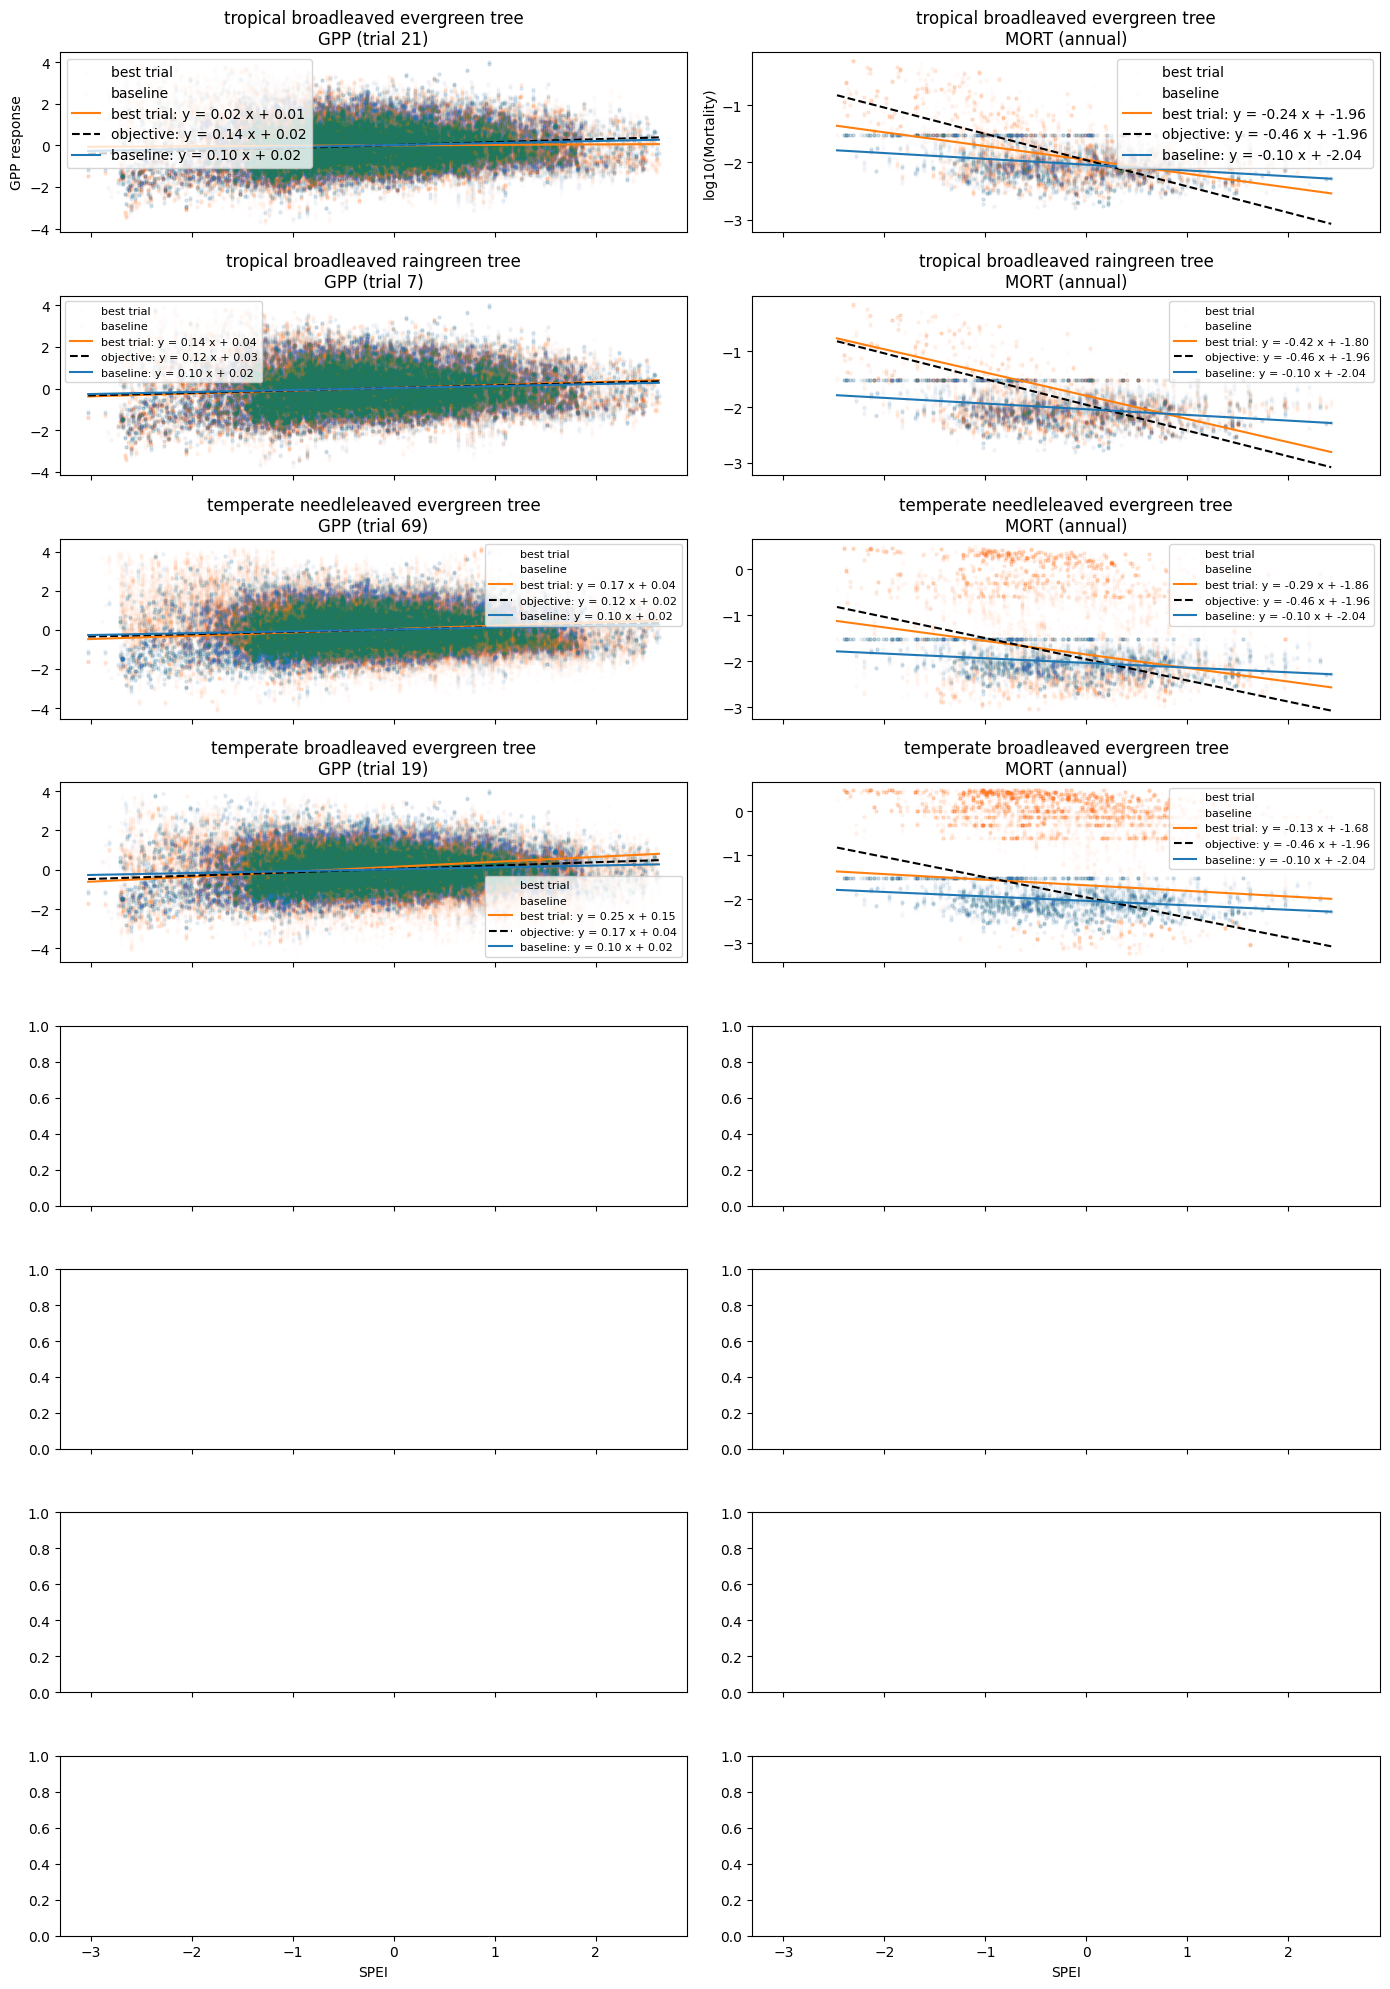

In [12]:
plot_gpp_mort_separated(
    knee_cache=knee_cache,
    OUTPUT_DIR=OUTPUT_DIR,
    BASELINE_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM",
    locations=locations,
    obs_spei=obs_spei,
    START_YEAR=2000,
    END_YEAR=2019,
    S_obs_gpp_water=S_obs_gpp_water,
    intercept_gpp=intercept_gpp,
    S_obs_mort=-0.46,
    intercept_mort=-1.96,
    standardized_anomalies=standardized_anomalies
)